In [2]:
import pandas as pd
import numpy as np
pd.options.display.float_format = "{:.1%}".format

# Momentum Strategies

## 2. Investigating Momentum

### Data

In this section, we empirically investigate some concerns regarding AQR’s new momentum product.  
On Canvas, find the data file, `data/momentum_data.xlsx`.

- The first tab contains the momentum factor as an excess return: $\tilde{r}^{\text{mom}}$.
- The second tab contains returns on portfolios corresponding to scored momentum deciles.  
  - $r^{\text{mom}(1)}$ denotes the portfolio of stocks in the lowest momentum decile, the “losers” with the lowest past returns.  
  - $r^{\text{mom}(10)}$ denotes the portfolio of stocks in the highest momentum decile.
- The third tab gives portfolios sorted by momentum and size.  
  - $r^{\text{momSU}}$ denotes the portfolio of small stocks in the top 3 deciles of momentum scores.  
  - $r^{\text{momBD}}$ denotes the portfolio of big stocks in the bottom 3 deciles of momentum scores.

Note that the Fama–French momentum return, $\tilde{r}^{\text{mom:FF}}$, given in the first tab, is constructed by FF as:

$$
\tilde{r}^{\text{mom:FF}} = 
\frac{1}{2} \left( r^{\text{momBU}} + r^{\text{momSU}} \right)
- \frac{1}{2} \left( r^{\text{momBD}} + r^{\text{momSD}} \right)
$$

The Fama–French momentum return:

$$
\tilde{r}^{\text{mom:FF}} = 
\frac{1}{2} \left( \tilde{r}^{\text{momBU}} + \tilde{r}^{\text{momSU}} \right)
- \frac{1}{2} \left( \tilde{r}^{\text{momBD}} + \tilde{r}^{\text{momSD}} \right)
$$

In [6]:
file_name = "momentum_data.xlsx"
sheet_name_1 = "momentum (excess returns)"
sheet_name_2 = "deciles (total returns)"
sheet_name_3 = "size_sorts (total returns)"
sheet_name_4 = "factors (excess returns)"
sheet_name_5 = "risk-free rate"

momentum_df = pd.read_excel(file_name, sheet_name=sheet_name_1, index_col='Date')
deciles_df = pd.read_excel(file_name, sheet_name=sheet_name_2, index_col='Date')
size_df = pd.read_excel(file_name, sheet_name=sheet_name_3, index_col='Date')
factors_df = pd.read_excel(file_name, sheet_name=sheet_name_4, index_col='Date')
risk_free_df =  pd.read_excel(file_name, sheet_name=sheet_name_5, index_col='Date')

In [4]:
stats_df = pd.concat([momentum_df, factors_df], axis = 1)
stats_df

,UMD,MKT,SMB,HML
Date,,,,
1927-01-31,0.6%,-0.1%,-0.3%,4.6%
1927-02-28,-1.5%,4.2%,0.1%,2.7%
1927-03-31,3.5%,0.1%,-1.8%,-2.4%
1927-04-30,4.4%,0.5%,0.4%,0.7%
1927-05-31,2.8%,5.5%,1.6%,4.8%
...,...,...,...,...
2025-04-30,5.0%,-0.8%,-0.6%,-3.4%
2025-05-31,2.2%,6.1%,0.7%,-2.9%
2025-06-30,-2.6%,4.9%,0.8%,-1.6%


# 2.1 Is Momentum sill profitable?

The excess returns of lucrative trading strategies often disappear once the strategy is well-known. The first widely-cited paper on momentum was published in 1993. Have momentum returns or risk changed since then? The AQR case takes place at the end of 2008. Have momentum returns changed in 2009-2024?

Investigate by filling out the summary statistics below for the full-sample and three sub-samples.

### (a)

Using the data provided, fill in Table 1 with the appropriate stats for $\tilde{r}^{\text{mom:FF}}$.

| Subsample | mean | vol | Sharpe | skewness | corr. to $\tilde{r}^m$ | corr. to $\tilde{r}^v$ |
|:-----------|:----:|:----:|:------:|:---------:|:----------------------:|:----------------------:|
| 1927 – 2024 |     |     |     |     |     |     |
| 1927 – 1993 |     |     |     |     |     |     |
| 1993 – 2008 |     |     |     |     |     |     |
| 2009 – 2024 |     |     |     |     |     |     |



In [5]:
#subsamples (1927-2024, 1927-1993, 1993-2008, 2009-2024)
periods = {
    "1927-2024": ["1927-01-01", "2024-12-31"],
    "1927-1993": ["1927-01-01", "1993-12-31"],
    "1993-2008": ["1993-01-01", "2008-12-31"],
    "2009-2024": ["2009-01-01", "2024-12-31"]
}

summary = pd.DataFrame()

for label, (start, end) in periods.items():
    subperiod = stats_df.loc[start:end]
    mean = subperiod["UMD"].mean() * 12
    vol = subperiod["UMD"].std() * np.sqrt(12)
    sharpe = mean/vol
    skew = subperiod["UMD"].skew()
    mkt_corr = subperiod["UMD"].corr(subperiod["MKT"])
    hml_corr = subperiod["UMD"].corr(subperiod["HML"])

    stats = pd.Series({
        "mean": mean,
        "vol": vol,
        "sharpe": sharpe,
        "skew": skew,
        "mkt_corr": mkt_corr,
        "hml_corr": hml_corr
    })

    summary[label] = stats

summary.T

,mean,vol,sharpe,skew,mkt_corr,hml_corr
1927-2024,7.4%,16.3%,45.4%,-306.7%,-34.9%,-41.0%
1927-1993,8.8%,16.1%,54.9%,-391.1%,-36.7%,-50.1%
1993-2008,10.9%,17.2%,63.7%,-63.1%,-23.1%,-9.2%
2009-2024,-1.3%,15.8%,-8.2%,-269.2%,-37.0%,-31.9%


## (b)

Has momentum changed much over time, as seen through these subsample statistics?

__BBetween the initial date and 2008, momentum did not change much, showing positive returns, stable volatility, and a similar Sharpe ratio. However, since 2009, it has been expected to generate negative excess returns.__


### (c)

Does this data support AQR’s argument that momentum is an important piece of the ideal portfolio?  
What if mean returns to momentum are in actuality near zero due to transaction costs — would there still be evidence here that momentum is valuable?

__Yes, in 2009 the expected excess returns reached their highest value. Additionally, in every period of the sample, the correlation with other factors is highly negative, making it a good factor for diversifying risk.__

### 2.2 Whether a long-only implementation of momentum is valuable

Construct your own long-only implementation:

$$
\tilde{r}^{\text{momU:FF}} = 
\frac{1}{2} 
\left(
\tilde{r}^{\text{momBU}} + 
\tilde{r}^{\text{momSU}}
\right)
- r^f
$$

Note that this is following the FF approach of treating big and small stocks separately.  
This would be very similar to a scaled version of:

$$
\tilde{r}^{\text{momU}} =
\frac{1}{3}
\left(
\tilde{r}^{\text{mom(8)}} +
\tilde{r}^{\text{mom(9)}} +
\tilde{r}^{\text{mom(10)}}
\right)
- r^f
$$

For the question below, use the FF-style $\tilde{r}^{\text{momU:FF}}_t$.


### (a)

Fill out Table 2 for the data in the period 1994–2024.

**Table 2: Long-only momentum performance.**

| 1994–2024 | mean | vol | Sharpe | skew | corr. to $\tilde{r}^m$ | corr. to ... |
|:--|:--:|:--:|:--:|:--:|:--:|:--:|
| Long-and-short, $(\tilde{r}^{\text{mom:FF}})$ |  |  |  |  |  |  |
| Long-only, $(\tilde{r}^{\text{momU:FF}})$ |  |  |  |  |  |  |


In [ ]:
long_portfolio_df = size_df["BIG HiPRIOR"] * 0.5 + size_df["SMALL HiPRIOR"] * 0.5 - risk_free_df["RF"]
long_portfolio_df = long_portfolio_df.loc["1994-01-01":]
portfolio_df = pd.merge(pd.DataFrame(portfolio_df, columns = ["long_port"]),
         stats_df,
         left_index= True, right_index=True)
portfolio_df = long_portfolio_df[["long_port", "MKT", "HML", 'UMD']]


In [26]:
summary = pd.DataFrame()


portfolio_name = "long_port"

mean = long_portfolio_df.mean() * 12
vol = long_portfolio_df.std() * np.sqrt(12)
sharpe = mean/vol
skew = long_portfolio_df.skew()
mkt_corr = long_portfolio_df.apply(lambda x: x.corr(long_portfolio_df["MKT"]))
hml_corr = long_portfolio_df.apply(lambda x: x.corr(long_portfolio_df["HML"]))

#hml_corr = subperiod["UMD"].corr(subperiod["HML"])

stats = pd.concat([mean, vol, sharpe, skew, mkt_corr, hml_corr], axis = 1)
#     "mean": mean,
#     "vol": vol,
#     "sharpe": sharpe,
#     "skew": skew,
#     "mkt_corr": mkt_corr,
#     "hml_corr": hml_corr
# })

#summary[label] = stats

stats.columns = ["mean", "vol", "sharpe", "skew", "mkt_corr", "hml_corr"]

In [27]:
stats

,mean,vol,sharpe,skew,mkt_corr,hml_corr
long_port,11.5%,17.8%,64.5%,-44.5%,90.5%,-12.4%
MKT,9.0%,15.5%,58.3%,-60.5%,100.0%,-9.6%
HML,1.5%,11.5%,13.0%,18.9%,-9.6%,100.0%
UMD,4.1%,16.6%,24.9%,-145.2%,-30.6%,-21.5%


### (b)

Is long-only momentum as attractive as long-short momentum with respect to mean, volatility, and Sharpe Ratio?

__Yes, even though volatility suffered a marginal increase, long only has better mean and sharpe ratio.__

### (c)

Is long-only momentum as diversifying as long-short momentum with respect to market and value premia?

__No, in the long only strategy the correlation with the market is positive, so, it does not diversified risk with that variable__

### (d)

Show a plot of the cumulative product of  
$(1 + \tilde{r}^{\text{mom:FF}})$ and $(1 + \tilde{r}^{\text{momU:FF}})$  
over the 1994–2024 subsample.vr

<Axes: xlabel='Date'>

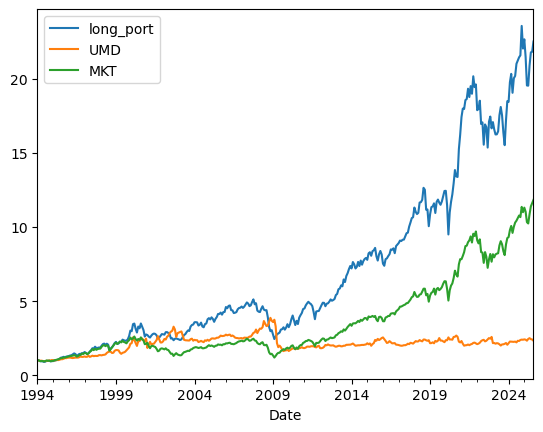

In [29]:
plot_df = long_portfolio_df[["long_port", "UMD", "MKT"]]
(plot_df + 1).cumprod().plot()

## 2.3

Is momentum just data mining, or is it a robust strategy?

Assess how sensitive the threshold for the “winners” and “losers” is in the results.  
Specifically, we compare three constructions:

- **Long the top 1 decile and short the bottom 1 decile:**

$$
\tilde{r}^{\text{momD1}} = r^{\text{mom}(10)} - r^{\text{mom}(1)}
$$

- **Long the top 3 deciles and short the bottom 3 deciles:**

$$
\tilde{r}^{\text{momD3}} =
\frac{1}{3} \left( r^{\text{mom}(8)} + r^{\text{mom}(9)} + r^{\text{mom}(10)} \right)
- \frac{1}{3} \left( r^{\text{mom}(3)} + r^{\text{mom}(2)} + r^{\text{mom}(1)} \right)
$$

or equivalently,

$$
\tilde{r}^{\text{momD3}} =
\frac{1}{3} \sum_{k=8}^{10} r^{\text{mom}(k)} -
\frac{1}{3} \sum_{k=1}^{3} r^{\text{mom}(k)}
$$

- **Long the top 5 deciles and short the bottom 5 deciles:**

$$
\tilde{r}^{\text{momD5}} =
\frac{1}{5} \sum_{k=6}^{10} r^{\text{mom}(k)} -
\frac{1}{5} \sum_{k=1}^{5} r^{\text{mom}(k)}
$$

In [ ]:
#long top 1 decile and short the bottom 1 decile:
portfolio_df = pd.DataFrame(deciles_df["Hi PRIOR"] - deciles_df["Lo PRIOR"], columns=["decile 1"])
portfolio_df["decile 3"] = deciles_df.iloc[:,-3:].sum(axis = 1) * (1/3) - deciles_df.iloc[:,:3].sum(axis = 1) * (1/3)
portfolio_df["decile 5"] = deciles_df.iloc[:,-5:].sum(axis = 1) * (1/5) - deciles_df.iloc[:,:5].sum(axis = 1) * (1/5)
portfolio_df = portfolio_df.loc["1994-01-01":]

In [47]:
summary = pd.DataFrame()

mean = portfolio_df.mean() * 12
vol = portfolio_df.std() * np.sqrt(12)
sharpe = mean/vol
skew = portfolio_df.skew()
mkt_corr = portfolio_df.apply(lambda x: x.corr(long_portfolio_df["MKT"]))
hml_corr = portfolio_df.apply(lambda x: x.corr(long_portfolio_df["HML"]))

#hml_corr = subperiod["UMD"].corr(subperiod["HML"])

stats = pd.concat([mean, vol, sharpe, skew, mkt_corr, hml_corr], axis = 1)
#     "mean": mean,
#     "vol": vol,
#     "sharpe": sharpe,
#     "skew": skew,
#     "mkt_corr": mkt_corr,
#     "hml_corr": hml_corr
# })

#summary[label] = stats

stats.columns = ["mean", "vol", "sharpe", "skew", "mkt_corr", "hml_corr"]

stats

,mean,vol,sharpe,skew,mkt_corr,hml_corr
decile 1,7.4%,29.9%,24.8%,-127.1%,-32.0%,-24.6%
decile 3,2.7%,19.3%,13.9%,-132.0%,-35.4%,-22.1%
decile 5,1.6%,13.4%,11.6%,-140.8%,-34.9%,-21.4%


## 2.4

### (b)

Do the tradeoffs between the 1-decile, 3-decile, and 5-decile constructions line up with the theoretical tradeoffs we discussed in the lecture?

__From 1994 to 2024, the 1-decile momentum portfolio delivers the highest return and Sharpe ratio but also the highest volatility and most negative skewness. The 3- and 5-decile constructions smooth volatility but reduce performance. All versions remain negatively correlated with market and value factors, confirming momentum’s diversification benefits.__


### (c)

Should AQR’s retail product consider using a 1-decile or 5-decile construction?

__The first decile is preferred because it has the highest Sharpe ratio, and its correlations with the market and value factors are negative. However, a 5-decile portfolio could also be a good choice, as it involves a lower probability of rebalancing — given the larger sample size, an asset is less likely to move from the momentum to the non-momentum category.__

### (d)

Does $\tilde{r}^{\text{momD3}}$ have similar stats to the Fama–French construction in (1)?  
Recall that construction is also a 3-decile, long–short construction, but it is segmented for small and large stocks.  

Compare the middle row of **Table 3** with the top row of **Table 2**.

## 2.4

Does implementing momentum require trading lots of small stocks — thus causing even larger trading costs?

For regulatory and liquidity reasons, AQR is particularly interested in using larger stocks for their momentum baskets.  
(Though they will launch one product that focuses on medium-sized stocks.)

Use the data provided on both small-stock “winners”, $r_t^{\text{momSU}}$, and small-stock “losers”, $r_t^{\text{momSD}}$,  
to construct a small-stock momentum portfolio:

$$
r_t^{\text{momS}} = r_t^{\text{momSU}} - r_t^{\text{momSD}}
$$

Similarly, use the data provided to construct a big-stock momentum portfolio:

$$
r_t^{\text{momB}} = r_t^{\text{momBU}} - r_t^{\text{momBD}}
$$

### (a)

Fill out Table 4 over the sample 1994–2024.

**Table 4: Momentum of small and big stocks.**

| 1994–2024 | mean | vol | Sharpe | skewness | corr. to $\tilde{r}^m$ |
|:--|:--:|:--:|:--:|:--:|:--:|
| All stocks, $\tilde{r}^{\text{mom:FF}}$ |  |  |  |  |  |
| Small stocks, $r_t^{\text{momS}}$ |  |  |  |  |  |
| Large stocks, $r_t^{\text{momB}}$ |  |  |  |  |  |

In [48]:
#size portfolios (all, small only, and big only)
size_portfolio_df = pd.DataFrame(size_df["SMALL HiPRIOR"] - size_df["SMALL LoPRIOR"], columns=["small only"])
size_portfolio_df["high only"] = size_df["BIG HiPRIOR"] - size_df["BIG LoPRIOR"]
size_portfolio_df["all stock"] = momentum_df["UMD"]

size_portfolio_df = size_portfolio_df.loc["1994-01-01":]

In [49]:
summary = pd.DataFrame()

mean = size_portfolio_df.mean() * 12
vol = size_portfolio_df.std() * np.sqrt(12)
sharpe = mean/vol
skew = size_portfolio_df.skew()
mkt_corr = size_portfolio_df.apply(lambda x: x.corr(long_portfolio_df["MKT"]))
hml_corr = size_portfolio_df.apply(lambda x: x.corr(long_portfolio_df["HML"]))

#hml_corr = subperiod["UMD"].corr(subperiod["HML"])

stats = pd.concat([mean, vol, sharpe, skew, mkt_corr, hml_corr], axis = 1)
#     "mean": mean,
#     "vol": vol,
#     "sharpe": sharpe,
#     "skew": skew,
#     "mkt_corr": mkt_corr,
#     "hml_corr": hml_corr
# })

#summary[label] = stats

stats.columns = ["mean", "vol", "sharpe", "skew", "mkt_corr", "hml_corr"]

stats

,mean,vol,sharpe,skew,mkt_corr,hml_corr
small only,6.2%,16.8%,36.9%,-181.3%,-30.9%,-13.9%
high only,2.1%,18.2%,11.4%,-85.5%,-27.3%,-26.5%
all stock,4.1%,16.6%,24.9%,-145.2%,-30.6%,-21.5%


## (b)

Is the attractiveness of the momentum strategy mostly driven by the small stocks? That is, does a momentum strategy in large stocks still deliver excess returns at comparable risk?

__Yes, the expected returns are higher than those of the Fama factors and small-size portfolios. Additionally, the correlations are negative, reinforcing momentum’s role as a diversifying source of return.__

## 2.5.

In conclusion, what is your assessment of the AQR retail product? Is it capturing the important features of the Fama-French construction of momentum? Would you suggest any modifications?

__The AQR retail momentum product effectively captures the main features of the Fama-French momentum factor. Its performance aligns with the academic construction, showing positive long-term excess returns and negative correlations with market and value factors, which provide diversification benefits.__